# ML Final Proyect
Installation things

In [ ]:
%pip install pandas rioxarray

## Load and trim map

         band_x          y          x  spatial_ref_x  esa_label_x  band_y  \
0             1  49.520042  10.950042              0           40       1   
1             1  49.520042  10.950125              0           40       1   
2             1  49.520042  10.950208              0           40       1   
3             1  49.520042  10.950292              0           40       1   
4             1  49.520042  10.950375              0           40       1   
...         ...        ...        ...            ...          ...     ...   
4036076       1  49.380042  11.149708              0           10       1   
4036077       1  49.380042  11.149792              0           10       1   
4036078       1  49.380042  11.149875              0           10       1   
4036079       1  49.380042  11.149958              0           10       1   
4036080       1  49.380042  11.150042              0           10       1   

         spatial_ref_y  esa_label_y  
0                    0           40  

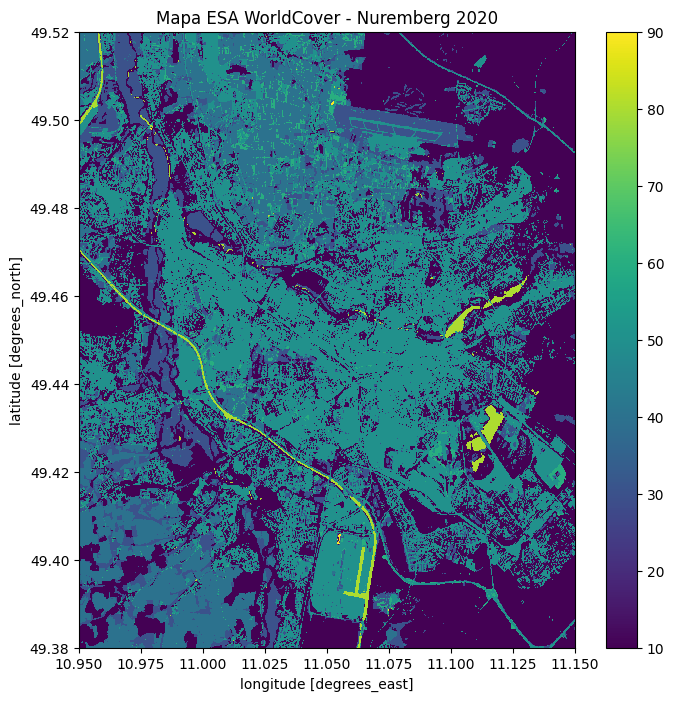

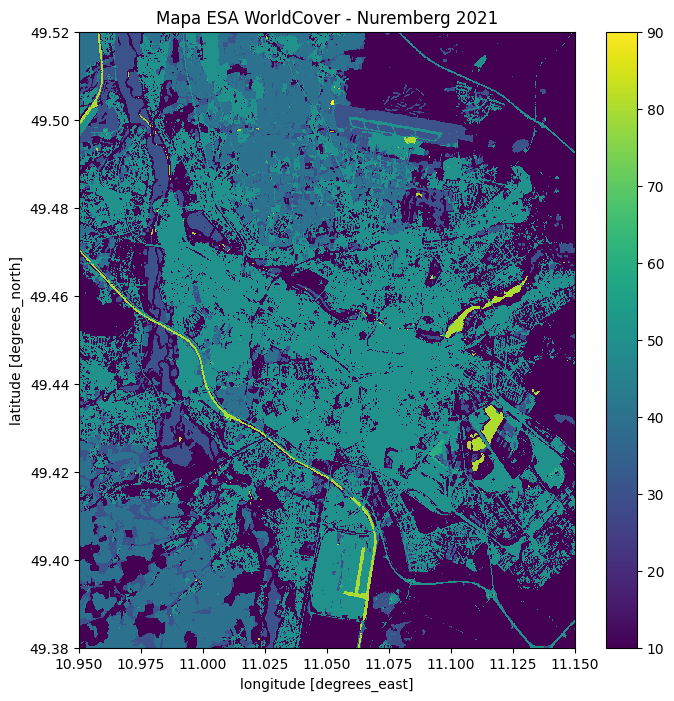

In [19]:
import rioxarray
import matplotlib.pyplot as plt

# Define Nürnberg bounds
bounds = (10.95, 49.38, 11.15, 49.52)

# Load ESA WorldCover for both years
esa_map_path_2020 = "ESA_WorldCover_10m_2020_v100_N48E009_Map.tif"
esa_map_path_2021 = "ESA_WorldCover_10m_2021_v200_N48E009_Map.tif"
esa_data_2020 = rioxarray.open_rasterio(esa_map_path_2020)
esa_data_2021 = rioxarray.open_rasterio(esa_map_path_2021)

# Frame for Nürnberg
esa_map_2020 = esa_data_2020.rio.clip_box(*bounds)
esa_map_2021 = esa_data_2021.rio.clip_box(*bounds)

df_2020 = esa_map_2020.to_dataframe(name="esa_label").reset_index()
df_2021 = esa_map_2021.to_dataframe(name="esa_label").reset_index()
# Renombramos columnas para que sean claras para el ML
df = df_2020.merge(df_2021, on=['x', 'y'])
#df = df.rename(columns={'x': 'longitude', 'y': 'latitude'})
#df_2021 = df_2021.rename(columns={'x': 'longitude', 'y': 'latitude'})

print(df)
# Visualizamos para confirmar que es Nuremberg
plt.figure(figsize=(8,8))
esa_map_2020.plot()
plt.title("Mapa ESA WorldCover - Nuremberg 2020")
plt.show()
plt.close()

plt.figure(figsize=(8,8))
esa_map_2021.plot()
plt.title("Mapa ESA WorldCover - Nuremberg 2021")
plt.show()
plt.close()

## Download data from satelllite Sentinel 2

In [ ]:
# Sentinel 2 data paht
sentinel_2_2020_B11_path = "Sentinel2_B11_20200730.tiff"
sentinel_2_2021_B11_path = "Sentinel2_B11_20210812.tiff"
sentinel_2_2020_RED_path = "Sentinel2_B3_4_8_20200730.tiff"
sentinel_2_2021_RED_path = "Sentinel2_B3_4_8_20210812.tiff"

# Get sentinel data to match with esa map
img_2020_B11 = rioxarray.open_rasterio(sentinel_2_2020_B11_path).rio.reproject_match(esa_map_2020)
img_2021_B11 = rioxarray.open_rasterio(sentinel_2_2021_B11_path).rio.reproject_match(esa_map_2020)
img_2020_RED = rioxarray.open_rasterio(sentinel_2_2020_RED_path).rio.reproject_match(esa_map_2020)
img_2021_RED = rioxarray.open_rasterio(sentinel_2_2021_RED_path).rio.reproject_match(esa_map_2020)


Function to get raster

In [ ]:
def raster_to_df(raster, prefix):
    # Convert dataset to get columns
    df = raster.to_dataset(name="val").drop_vars("spatial_ref", errors="ignore").to_dataframe()
    
    # Each band as a column
    df = df.unstack('band')
    
    # Rename columns
    num_bands = len(df.columns)
    df.columns = [f'{prefix}_b{i}' for i in range(1, num_bands + 1)]
    
    return df.reset_index()

In [ ]:
# Process images to get all columns and same format
df_b11_2020 = raster_to_df(img_2020_B11, "b11_2020")
df_b11_2021 = raster_to_df(img_2021_B11, "b11_2021")
df_red_2020 = raster_to_df(img_2020_RED, "red_2020")
df_red_2021 = raster_to_df(img_2021_RED, "red_2021")

# Clean data before merge
df_esa_2020 = esa_map_2020.to_dataset(name="label_2020").drop_vars("spatial_ref", errors="ignore").to_dataframe().reset_index()
df_esa_2021 = esa_map_2021.to_dataset(name="label_2021").drop_vars("spatial_ref", errors="ignore").to_dataframe().reset_index()

# Final merge
print("Creating Master DataFrame...")
master_df = df_esa_2020.merge(df_esa_2021, on=['x', 'y']) \
                       .merge(df_red_2020, on=['x', 'y']) \
                       .merge(df_b11_2020, on=['x', 'y']) \
                       .merge(df_red_2021, on=['x', 'y']) \
                       .merge(df_b11_2021, on=['x', 'y'])

# 5. Renombrado final para ML
master_df = master_df.rename(columns={
    'x': 'longitude', 'y': 'latitude','red_2020_b1': 'b8_2020', 'red_2020_b2': 'b4_2020', 'red_2020_b3': 'b3_2020',
    'b11_2020_b1': 'b11_2020', 'red_2021_b1': 'b8_2021', 'red_2021_b2': 'b4_2021','red_2021_b3':'b3_2021','b11_2021_b1':'b11_2021'
    })

print("¡Éxito! Columnas en el dataset:", master_df.columns.tolist())

# Guardamos el CSV final
master_df.to_csv("nuremberg_dataset_final.csv", index=False)
print(master_df.head())

Creating Master DataFrame...
¡Éxito! Columnas en el dataset: ['band_x', 'longitude', 'latitude', 'label_2020', 'band_y', 'label_2021', 'b3_2020', 'b4_2020', 'b8_2020', 'b11_2020', 'b3_2021', 'b4_2021', 'b8_2021', 'b11_2021']
   band_x  longitude   latitude  label_2020  band_y  label_2021  b3_2020  \
0       1  10.950042  49.520042          40       1          40    54657   
1       1  10.950042  49.519958          40       1          40    54133   
2       1  10.950042  49.519875          40       1          40    56033   
3       1  10.950042  49.519792          40       1          40    56033   
4       1  10.950042  49.519708          40       1          40    58655   

   b4_2020  b8_2020  b11_2020  b3_2021  b4_2021  b8_2021  b11_2021  
0    12911    11502     12013    33636    24478    16450     18114  
1    11895    10289     11908    35488    25494    16777     19870  
2     9667     8880     11423    35488    25494    16777     19870  
3     9667     8880     11423    42140    